### **[Exploring Income Patterns with Python](https://towardsdatascience.com/from-raw-census-data-to-powerful-insights-exploring-income-patterns-with-pandas-matplotlib-seaborn/)**

> *A Beginner-Friendly Exploratory Data Analysis on the US Census Dataset*

In [1]:
!pip install -qq --upgrade kaggle

!kaggle datasets download uciml/adult-census-income

!unzip -q /content/adult-census-income.zip -d /content/adult-census-income/ && rm /content/adult-census-income.zip

!ls /content/adult-census-income/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.8/243.8 kB 6.2 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/uciml/adult-census-income
License(s): CC0-1.0
100% 450k/450k [00:00<00:00, 80.8MB/s]

adult.csv


In [2]:
import sys

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

IN_COLAB = 'google.colab' in sys.modules

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)
np.set_printoptions(precision=3, suppress=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_colwidth', None)

sns.set_style('whitegrid')

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['figure.dpi'] = 200

%autosave 15

Autosaving every 15 seconds


In [3]:
df = pd.read_csv('/content/adult-census-income/adult.csv')
display(df.head(10))

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K
7,74,State-gov,88638,Doctorate,16,Never-married,Prof-specialty,Other-relative,White,Female,0,3683,20,United-States,>50K
8,68,Federal-gov,422013,HS-grad,9,Divorced,Prof-specialty,Not-in-family,White,Female,0,3683,40,United-States,<=50K
9,41,Private,70037,Some-college,10,Never-married,Craft-repair,Unmarried,White,Male,0,3004,60,?,>50K


In [4]:
rows, cols = df.shape[0], df.shape[1]
print(f"Adult Income Census: {rows} rows, {cols} columns/features.")

Adult Income Census: 32561 rows, 15 columns/features.


In [5]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


None

In [6]:
print("Before cleaning:", len(df))
df = df.replace("?", pd.NA).dropna()
print("After cleaning:", len(df))

Before cleaning: 32561
After cleaning: 30162


#### **General Income Analysis**

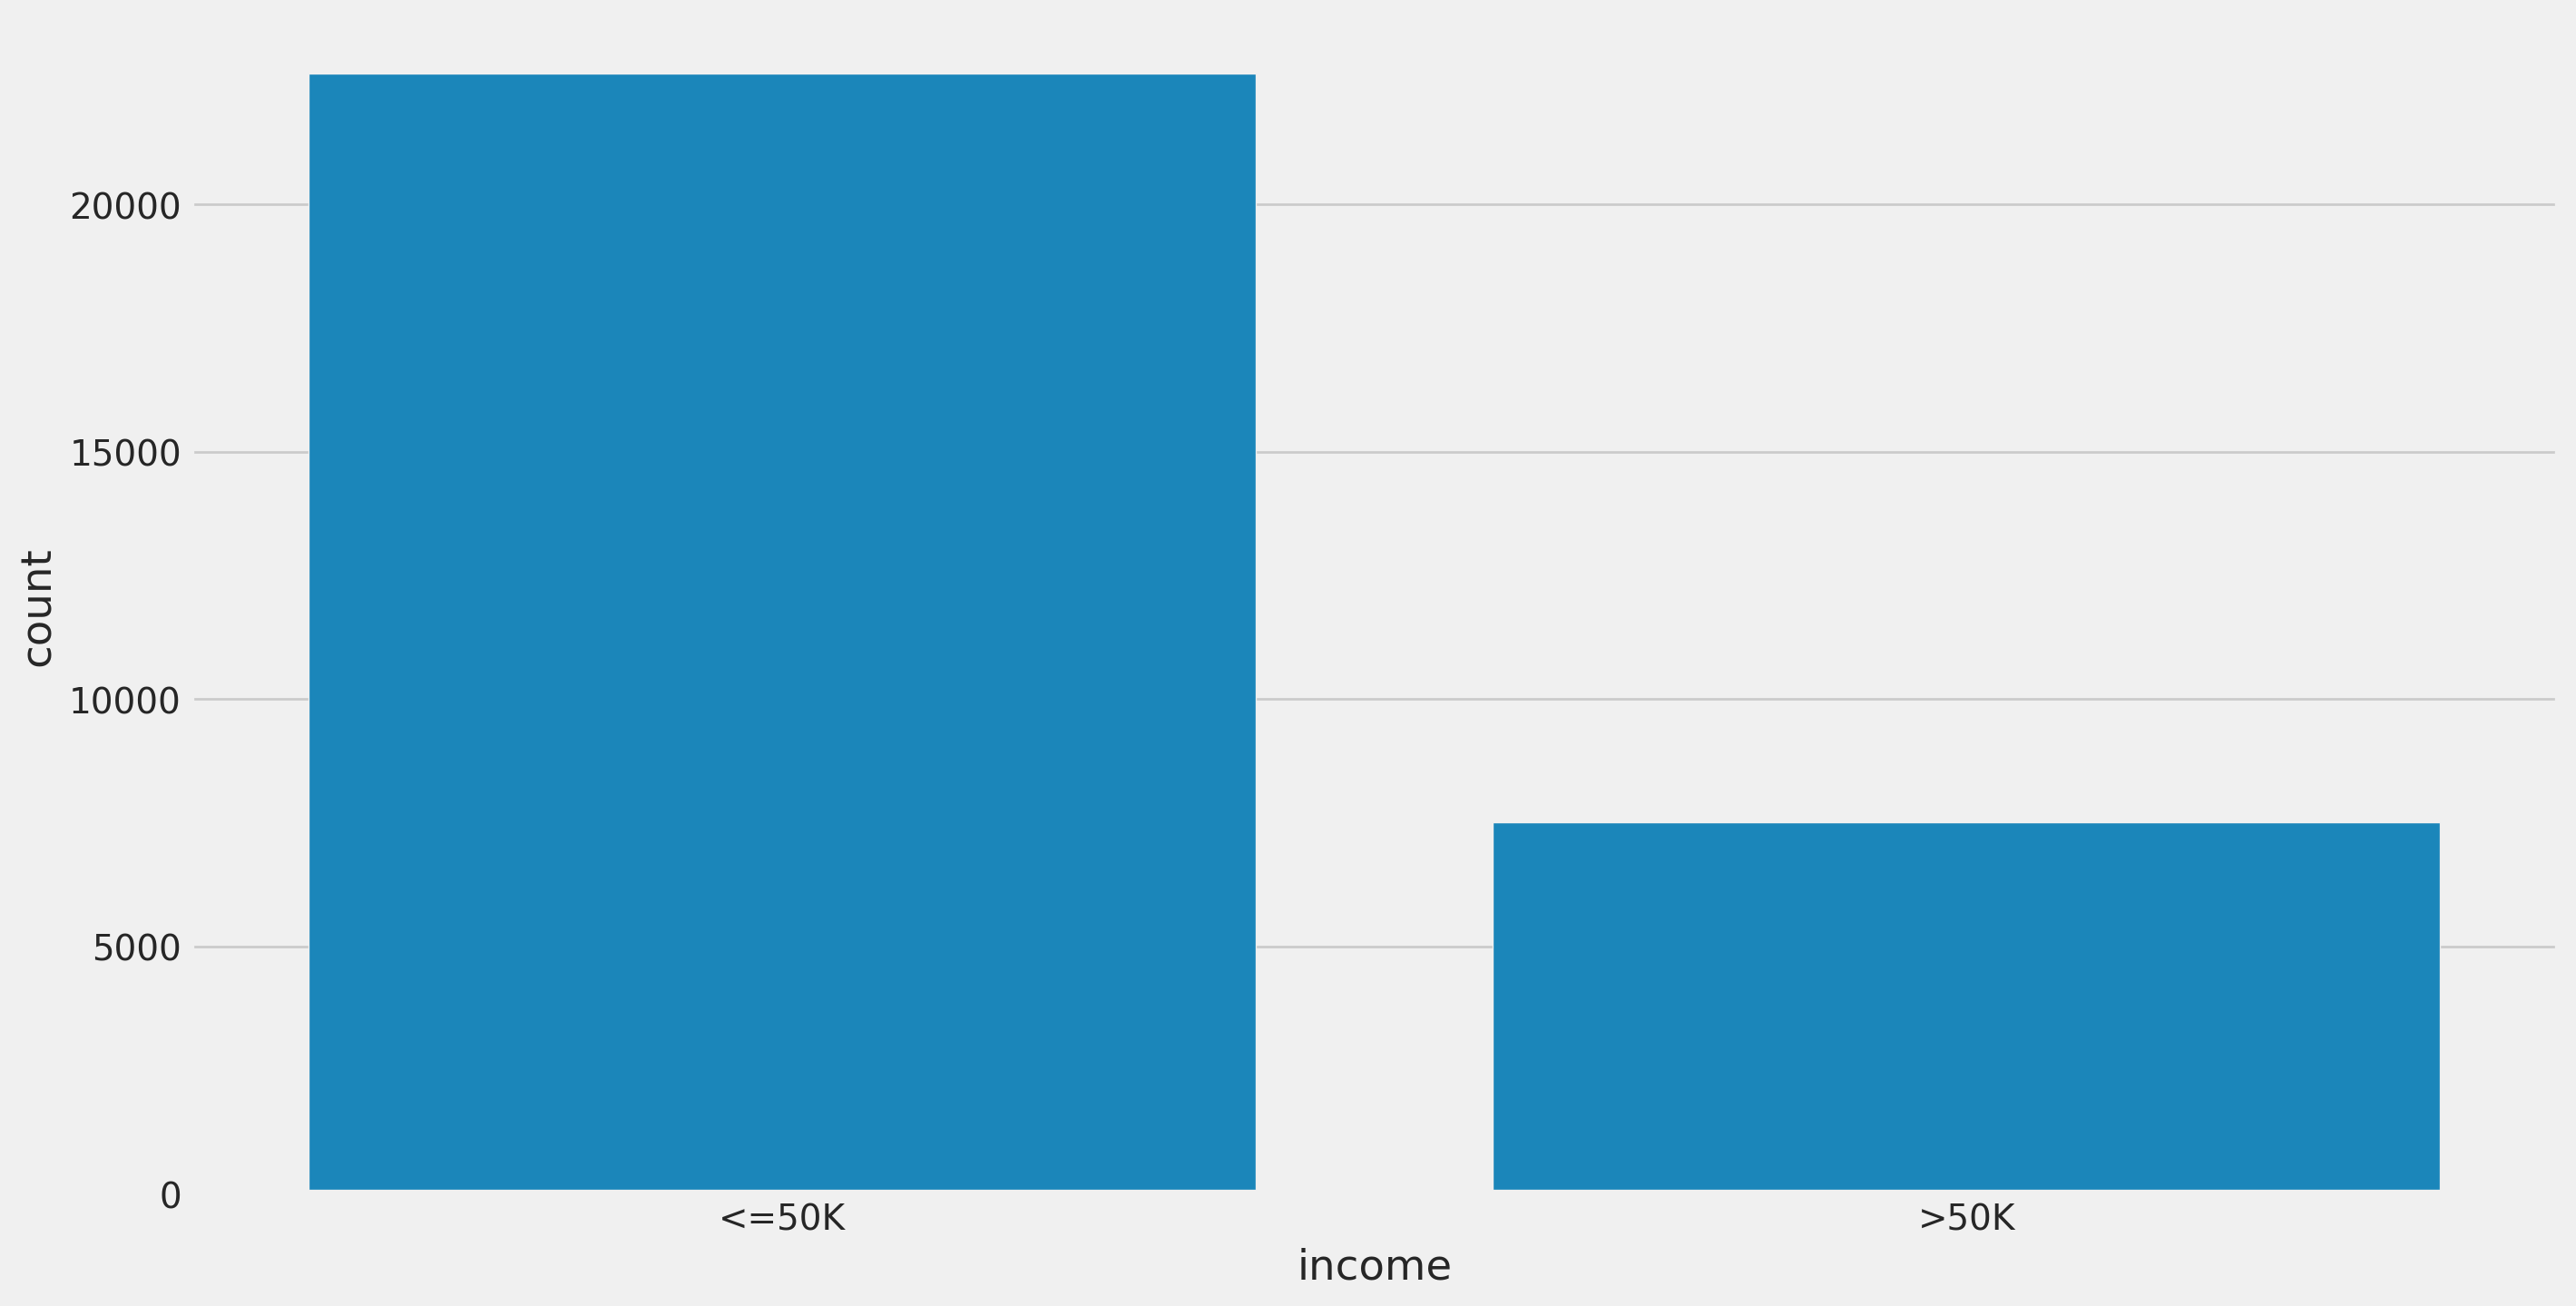

In [7]:
# Income Graph
sns.countplot(x="income", data=df)
plt.show()

#### **Income in relation to Education Analysis**

In [8]:
#Eductaion & Income Relationship
result = df.groupby("education")["income"].value_counts()
display(result)

education     income
10th          <=50K      761
              >50K        59
11th          <=50K      989
              >50K        59
12th          <=50K      348
              >50K        29
1st-4th       <=50K      145
              >50K         6
5th-6th       <=50K      276
              >50K        12
7th-8th       <=50K      522
              >50K        35
9th           <=50K      430
              >50K        25
Assoc-acdm    <=50K      752
              >50K       256
Assoc-voc     <=50K      963
              >50K       344
Bachelors     <=50K     2918
              >50K      2126
Doctorate     >50K       280
              <=50K       95
HS-grad       <=50K     8223
              >50K      1617
Masters       >50K       918
              <=50K      709
Preschool     <=50K       45
Prof-school   >50K       406
              <=50K      136
Some-college  <=50K     5342
              >50K      1336
Name: count, dtype: int64

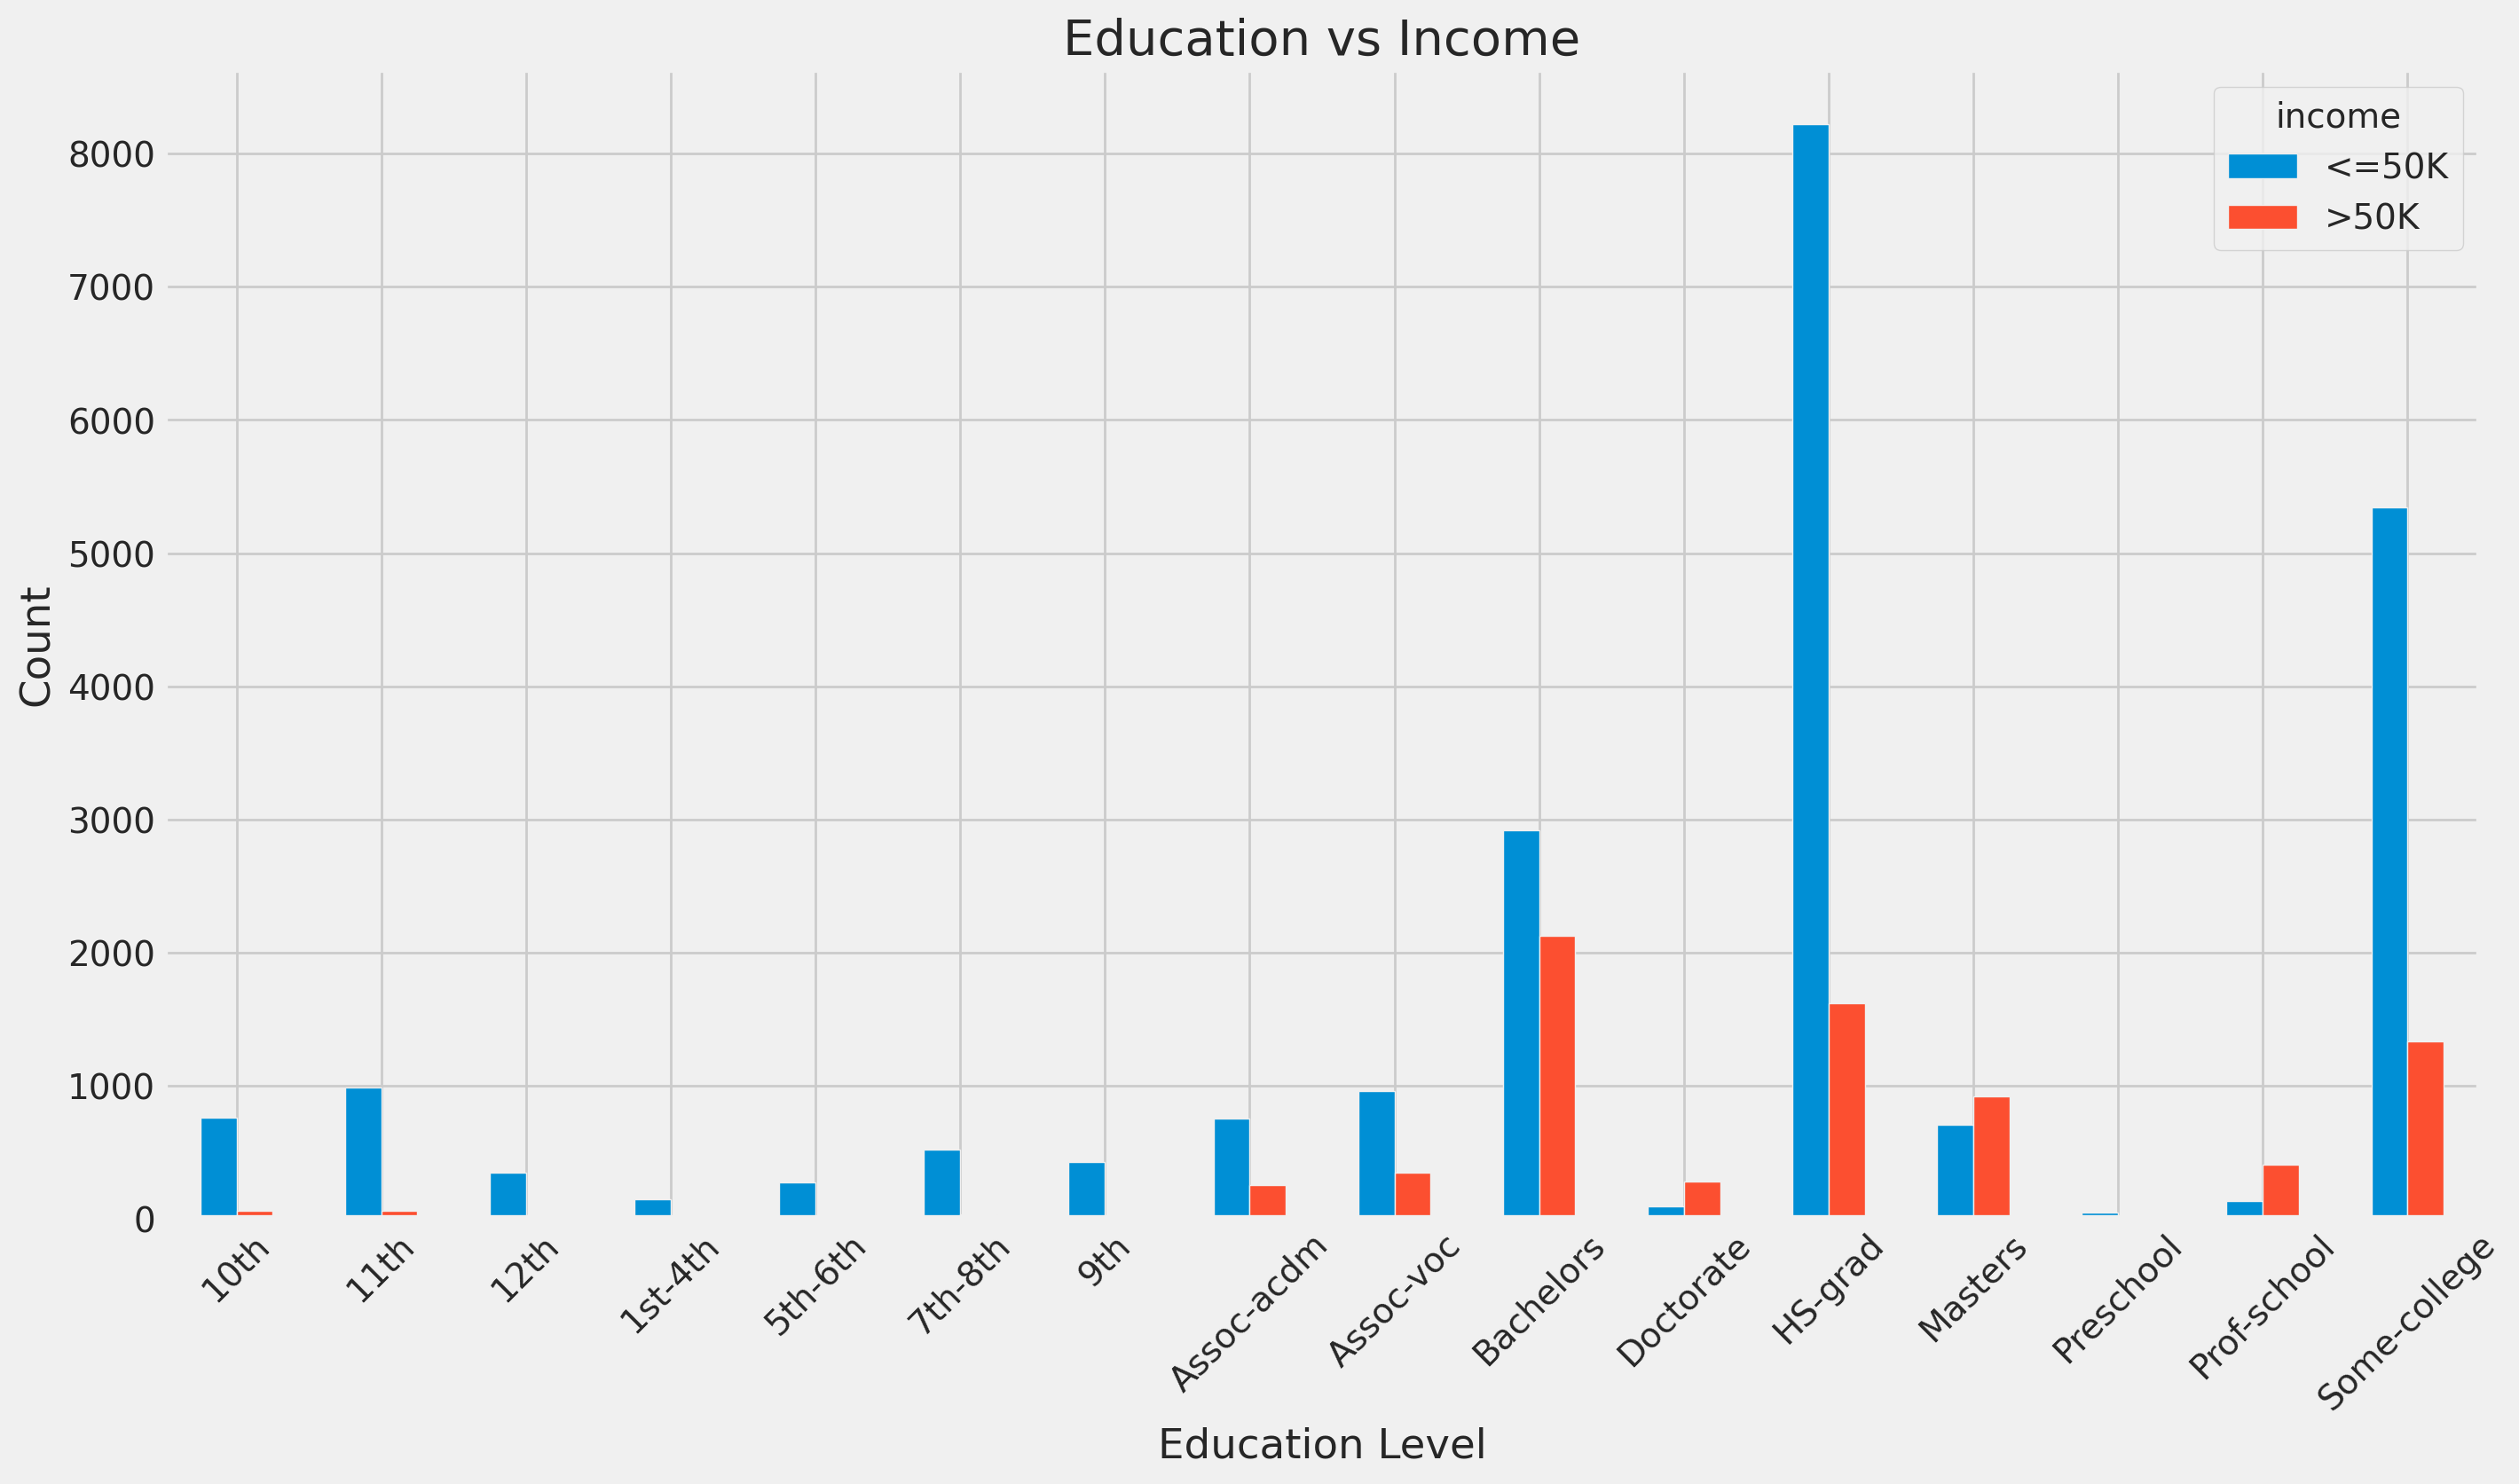

In [9]:
#Eductaion & Income Relationship
result = df.groupby("education")["income"].value_counts().unstack()
# Plot
result.plot(kind="bar", figsize=(15,8))
# Labels and title
plt.title("Education vs Income")
plt.xlabel("Education Level")
plt.ylabel("Count")
plt.xticks(rotation=45)
# Show graph
plt.show()

#### **Income in relation to Hours per Week Analysis**

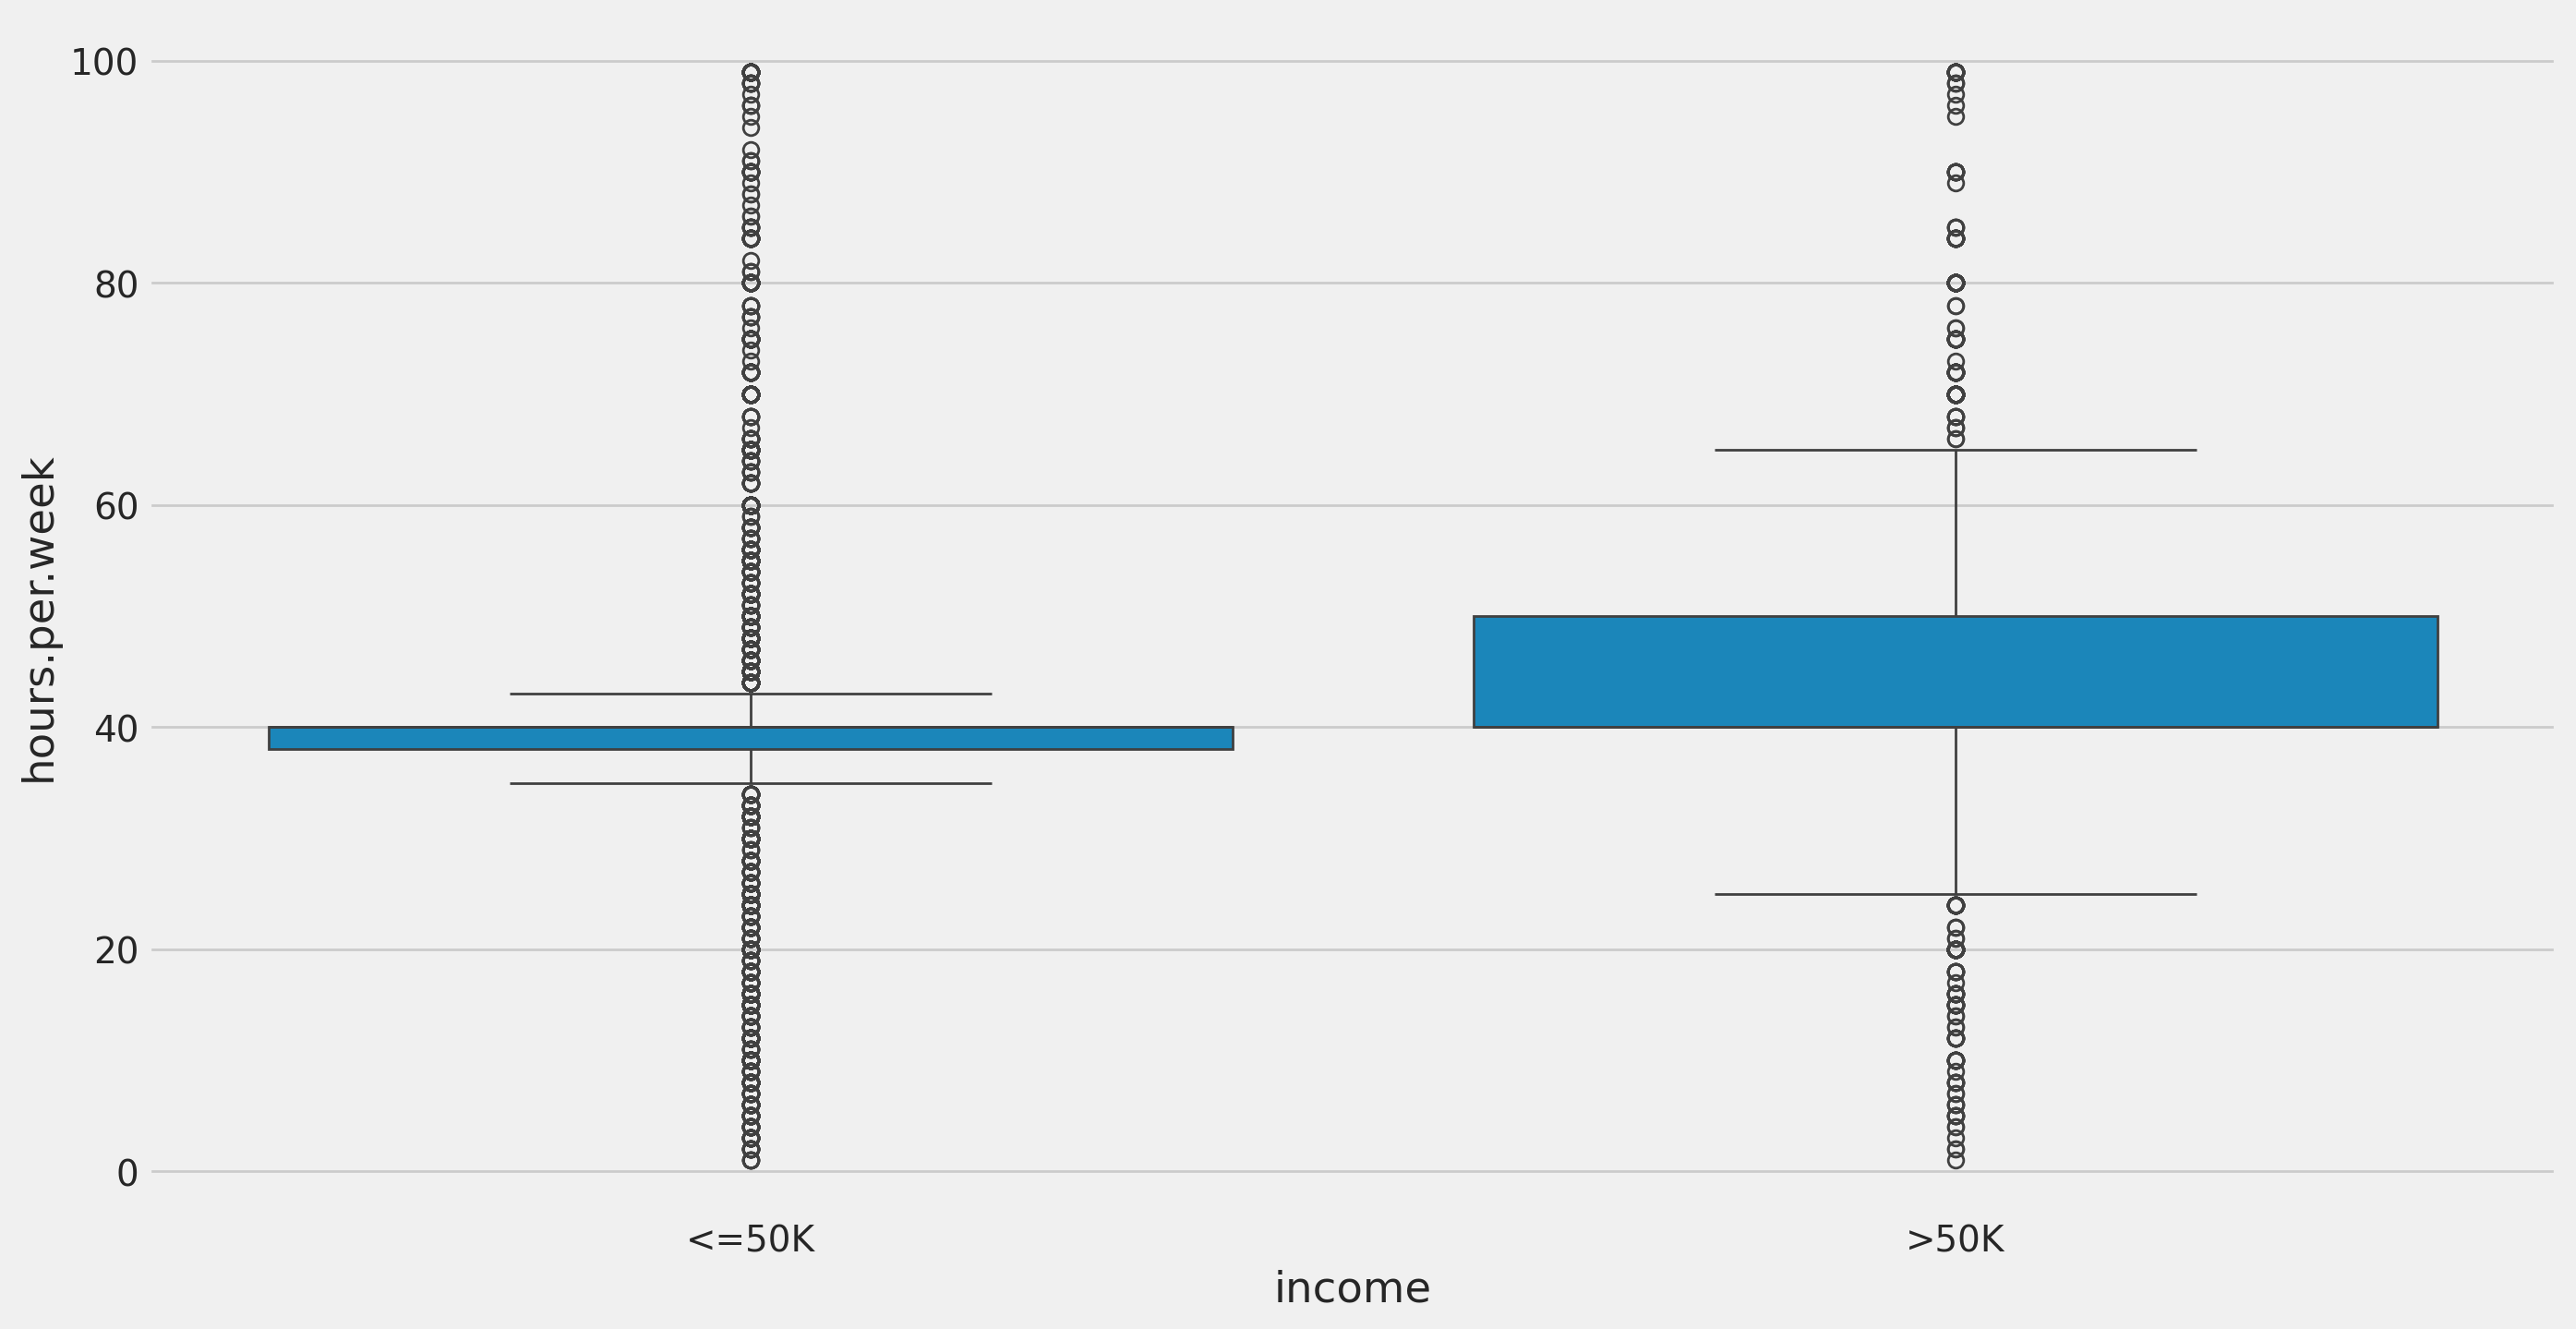

In [10]:
# Show graph
sns.boxplot(x="income", y="hours.per.week", data=df)
plt.show()

#### **Income in relation to Gender Analysis**

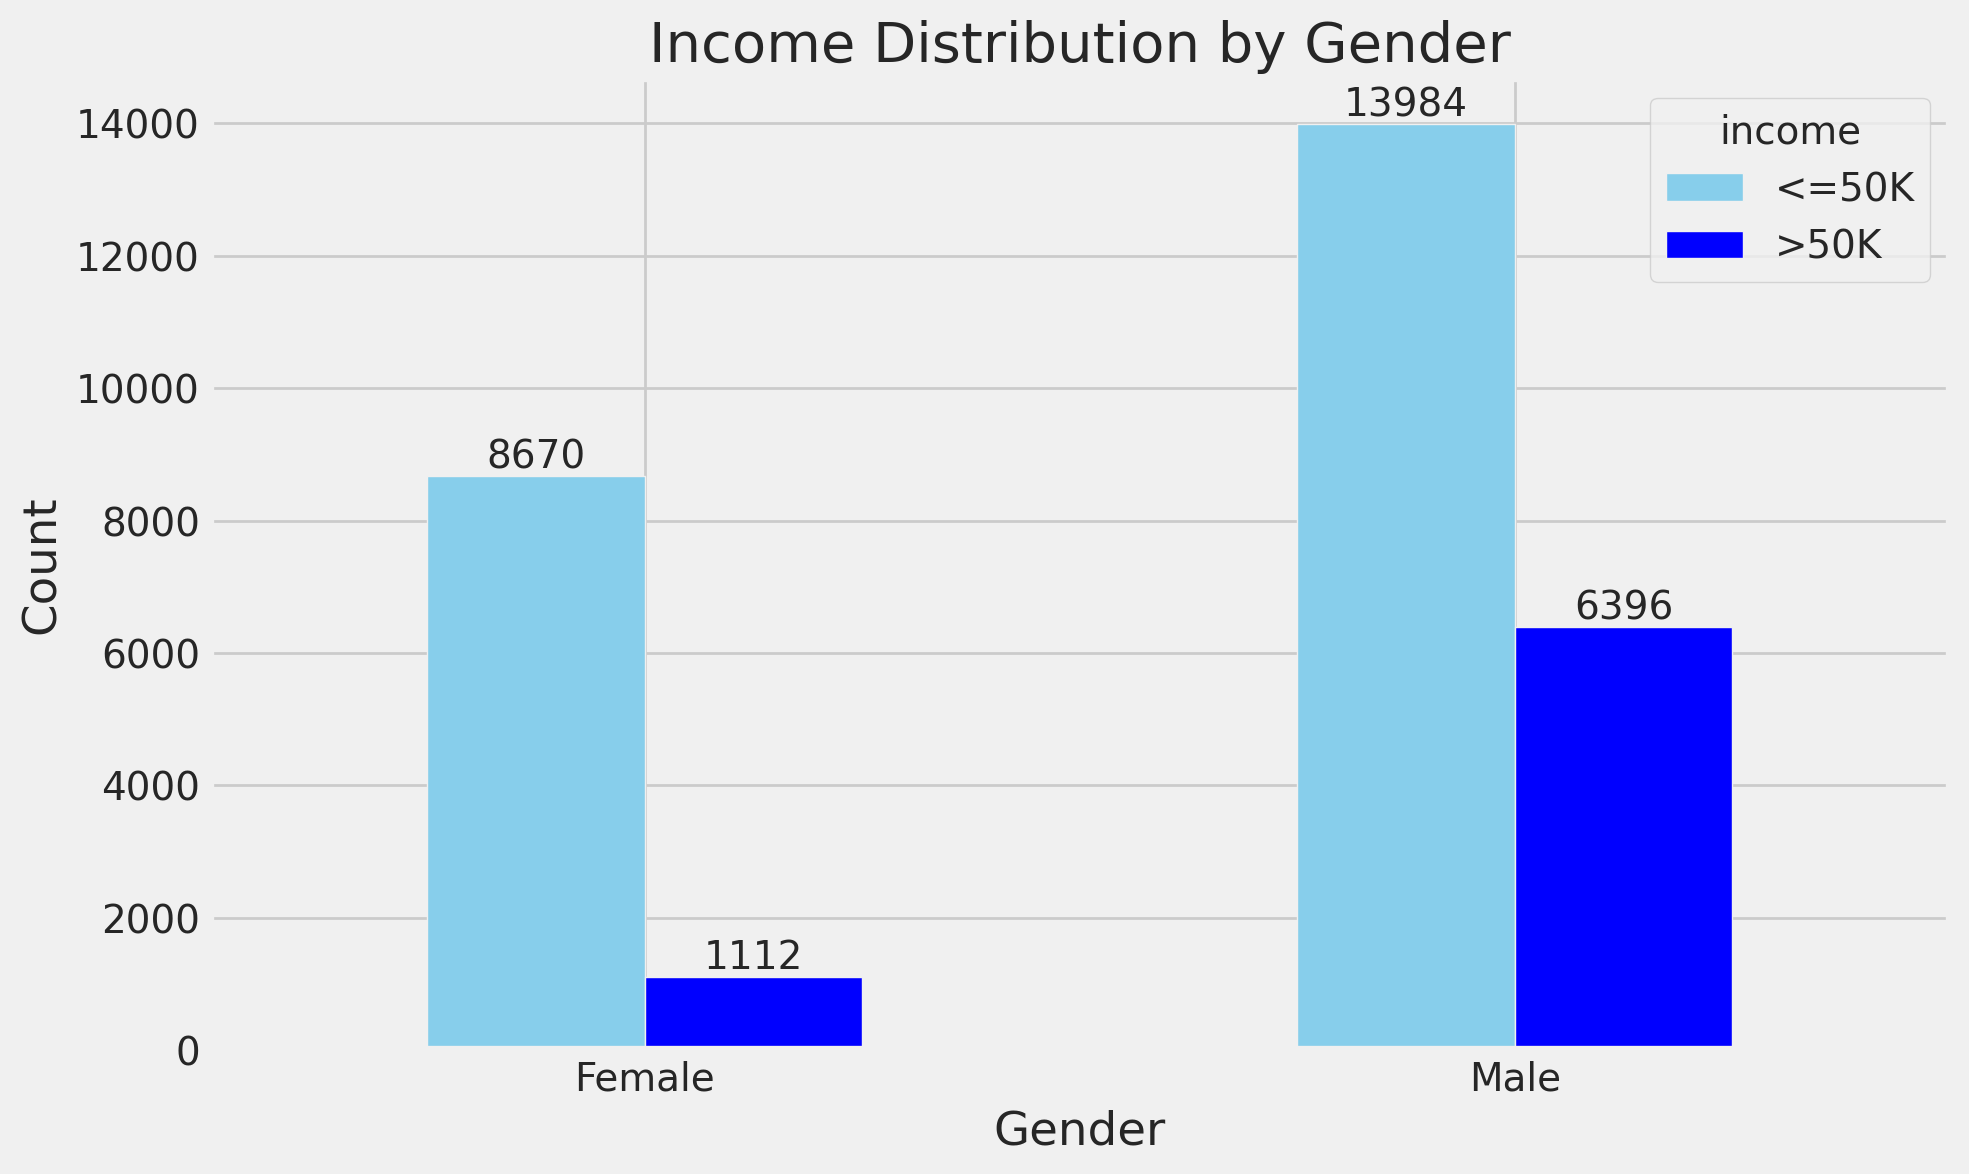

In [11]:
result = df.groupby("sex")["income"].value_counts().unstack()

# Plot with custom colors
ax = result.plot(
    kind="bar",
    figsize=(10,6),
    color=["skyblue", "blue"]
)

# Add labels on bars
for container in ax.containers:
  ax.bar_label(container)

# Titles and labels
plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Show graph
plt.show()

#### **Income in relation to Workclass Analysis**

array(['Private', 'State-gov', 'Federal-gov', 'Self-emp-not-inc',
       'Self-emp-inc', 'Local-gov', 'Without-pay'], dtype=object)

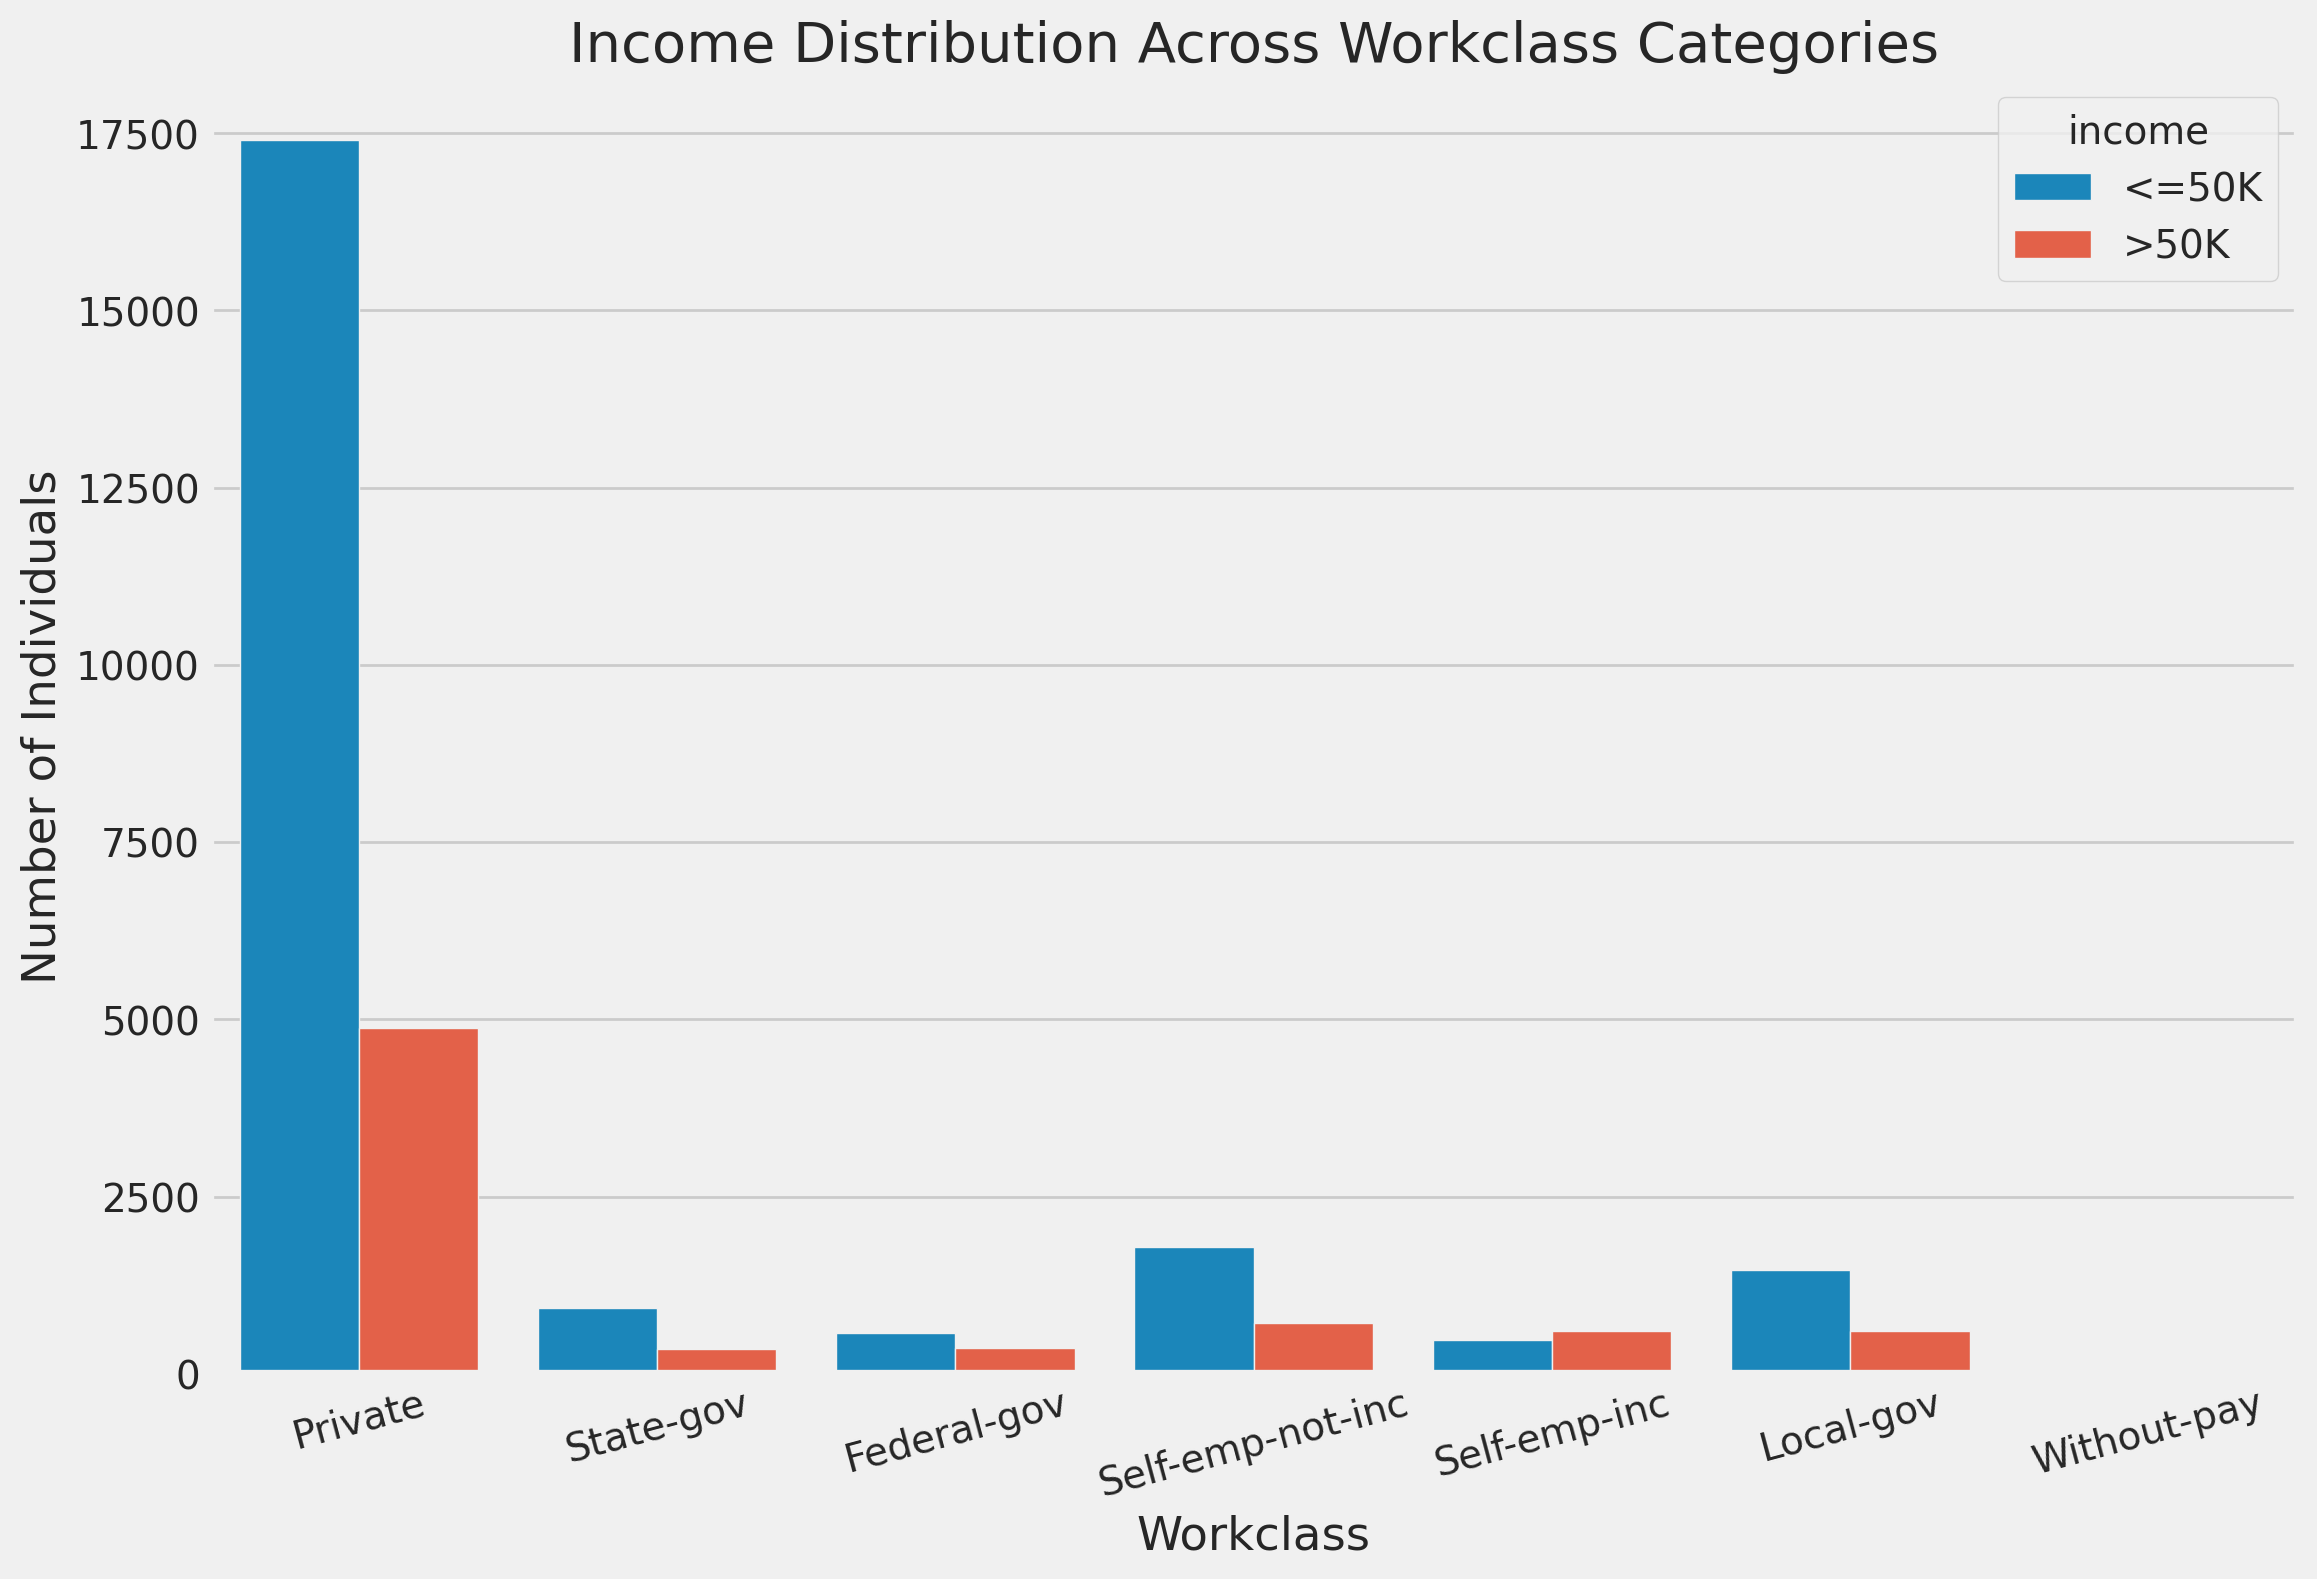

In [12]:
display(df["workclass"].unique())

# Select workclasses
top_workclasses = df["workclass"].value_counts().head(7).index

filtered_df = df[df["workclass"].isin(top_workclasses)]

# Create chart
plt.figure(figsize=(12, 8))

sns.countplot(
  data=filtered_df,
  x="workclass",
  hue="income"
)

# Titles and labels
plt.title("Income Distribution Across Workclass Categories")
plt.xlabel("Workclass")
plt.ylabel("Number of Individuals")

plt.xticks(rotation=15)

plt.show()


#### **Income in relation to Occupation Analysis**

In [13]:
result = df[df["income"] == ">50K"]["occupation"].value_counts().head(10)
display(result)

,count
occupation,
Exec-managerial,1937
Prof-specialty,1811
Sales,970
Craft-repair,908
Adm-clerical,498
Transport-moving,319
Tech-support,278
Machine-op-inspct,245
Protective-serv,210


#### **Income in relation to Age Analysis**

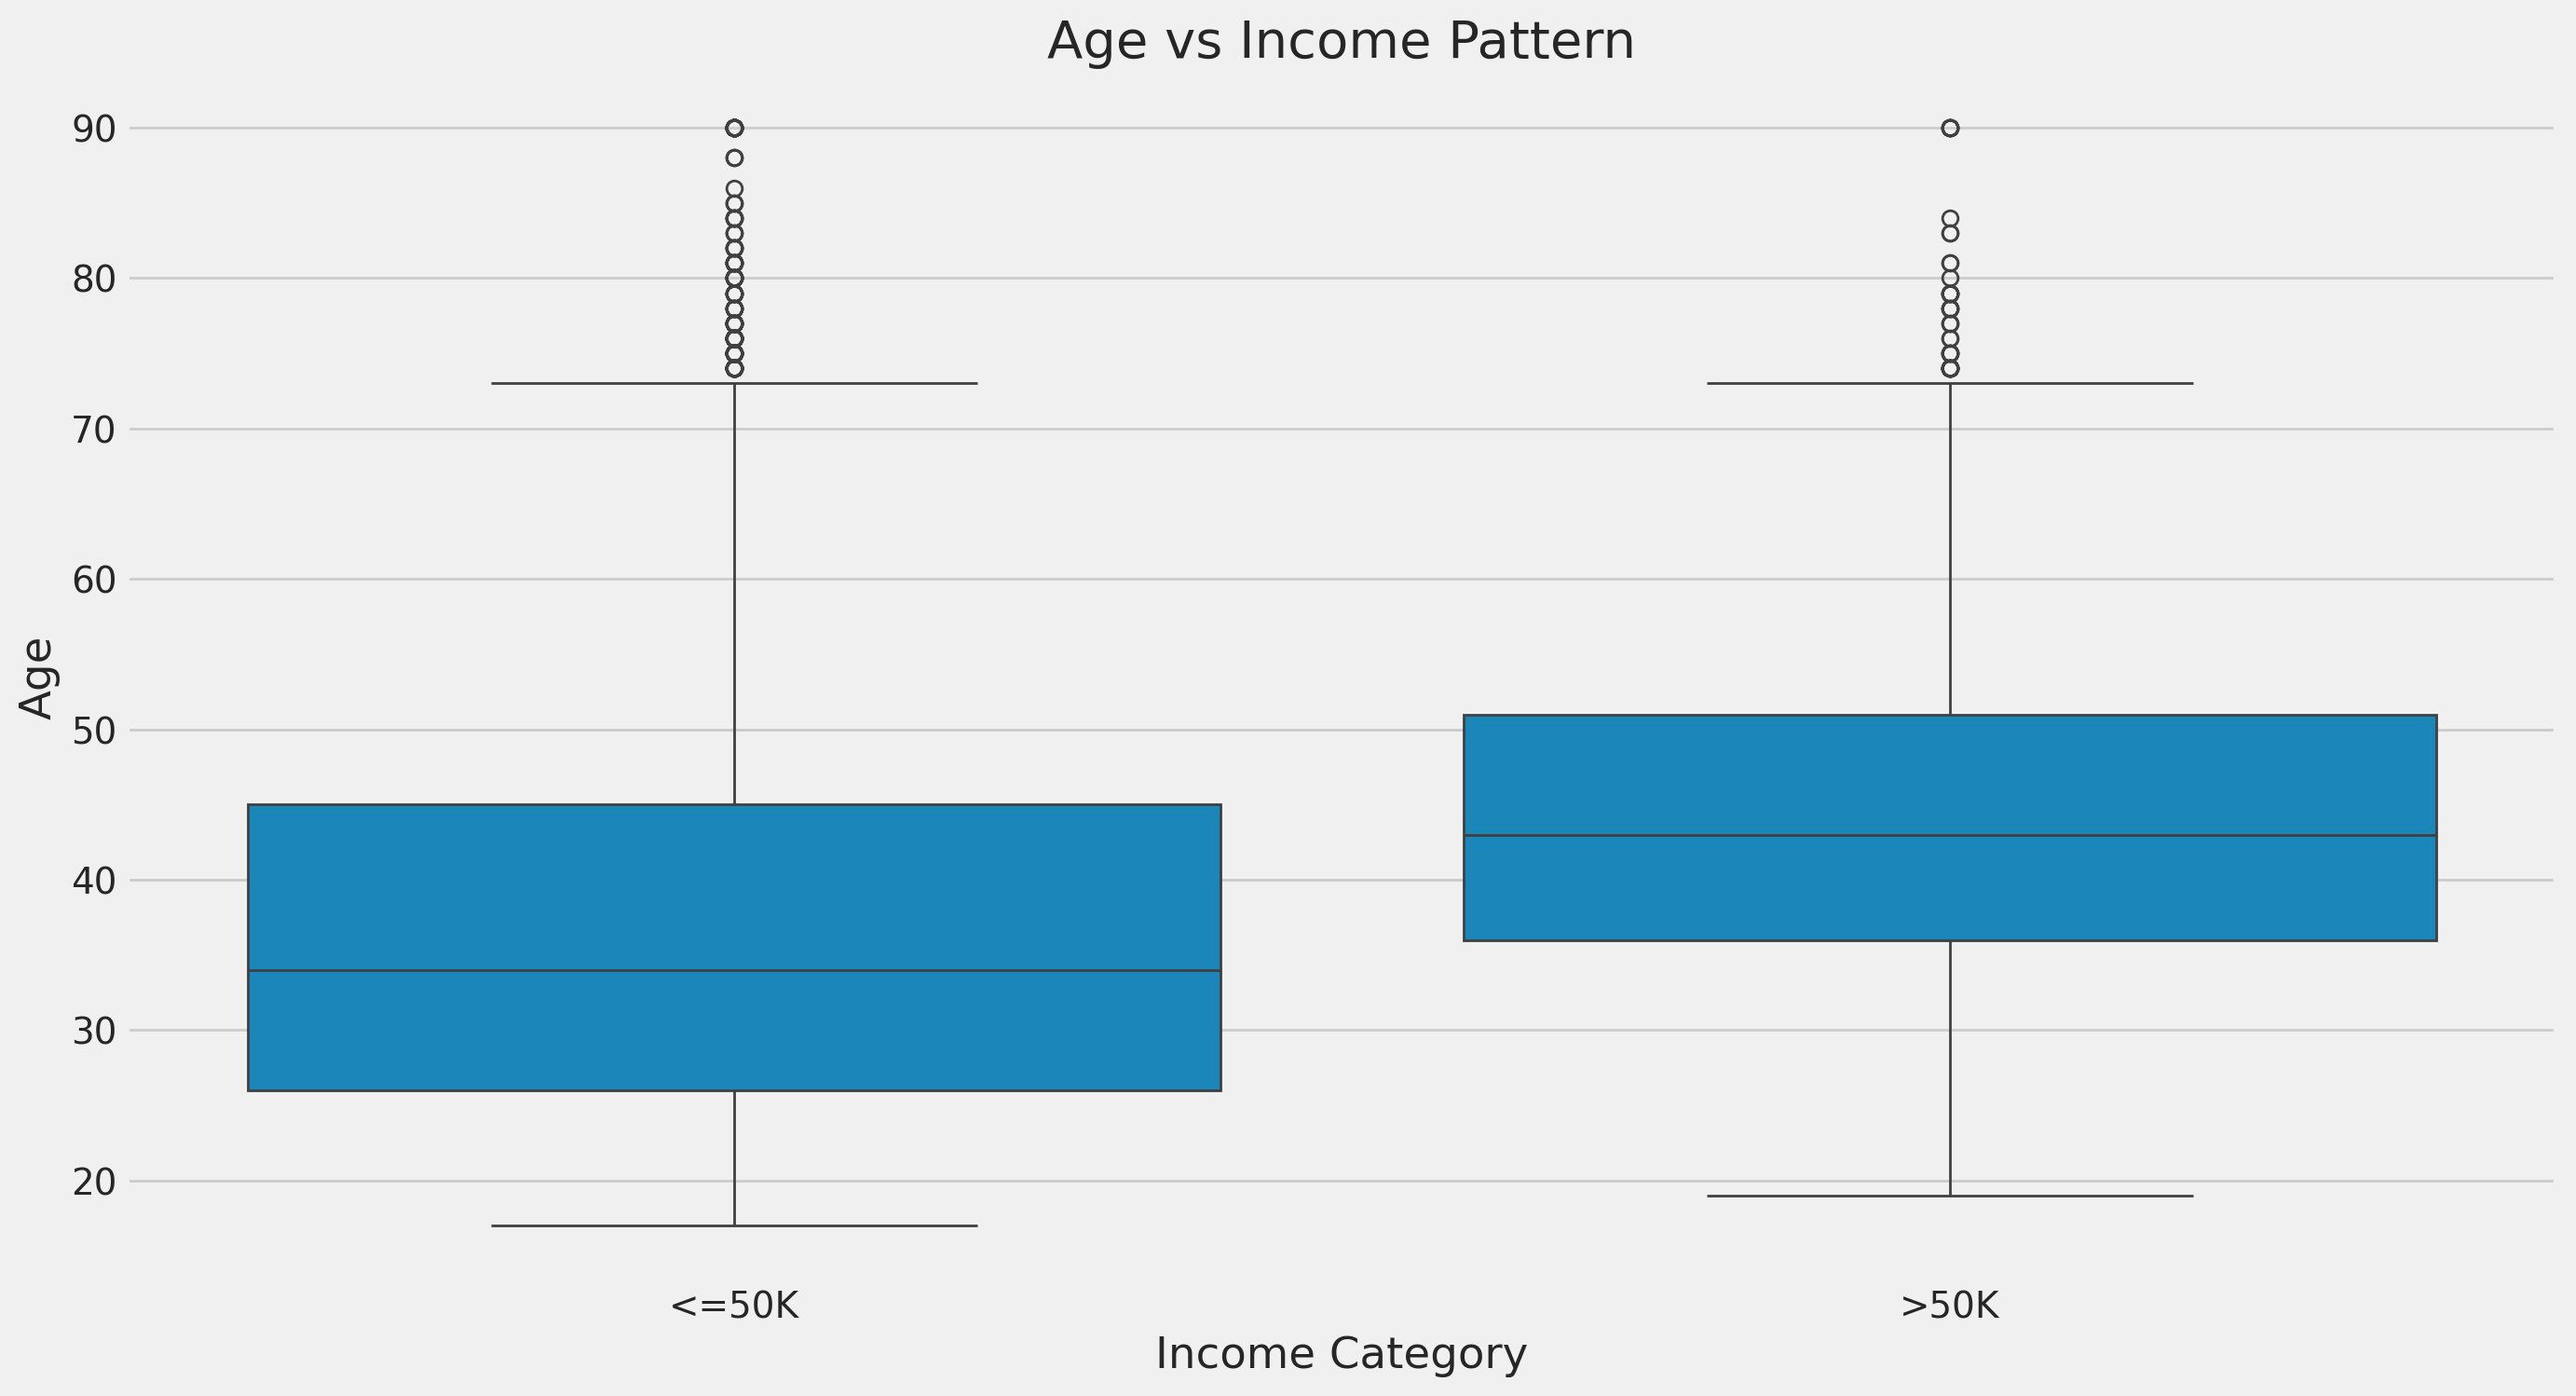

In [14]:
# Create figure
plt.figure(figsize=(15,8))

# Boxplot
sns.boxplot(
  x="income",
  y="age",
  data=df
)

# Titles and labels
plt.title("Age vs Income Pattern")
plt.xlabel("Income Category")
plt.ylabel("Age")

# Show graph
plt.show()